In [67]:
import tempfile
from datetime import datetime

from kfp.dsl import Dataset, Model, Metrics


# =========================================================
# CONFIG
# =========================================================

PROJECT_ID = "bq-pfu-ga4"
BQ_DATASET = "BQ_PFU_INCIPY"
BQ_TABLE = "lead_scoring_train"

RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")

print("===================================================")
print("LOCAL PIPELINE RUN")
print("RUN ID:", RUN_ID)
print("===================================================")


LOCAL PIPELINE RUN
RUN ID: 20260603_204723


In [68]:
import pandas as pd
from google.cloud import bigquery
from collections import namedtuple
import logging

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger()

client = bigquery.Client(project=PROJECT_ID)

query = f"""
    SELECT
        *
    FROM `{PROJECT_ID}.{BQ_DATASET}.{BQ_TABLE}`
    """

df = client.query(query).to_dataframe()

In [69]:
df.columns

Index(['event_timestamp', 'user_pseudo_id', 'ga_session_id',
       'ga_session_number', 'transaction_id', 'product_id', 'product_area',
       'product_type', 'product_campus', 'product_modality',
       'product_dedication', 'form_type', 'form_subtype', 'form_level',
       'form_display', 'form_position', 'form_time_lapse', 'form_on_page',
       'page_section', 'page_type', 'page_path', 'language_site',
       'market_site', 'platform', 'brand', 'consent_status', 'page_referrer',
       'user_country', 'user_province', 'user_studies', 'utm_source',
       'utm_medium', 'utm_campaign', 'has_fbclid', 'has_gclid', 'segmento',
       'nav_disponible', 'pageviews_pre', 'view_item_pre',
       'distinct_products_pre', 'view_item_list_pre', 'view_content_pre',
       'select_item_pre', 'search_pre', 'scroll_pre', 'flag_add_to_cart',
       'flag_begin_checkout', 'flag_file_download', 'flag_open_chat',
       'flag_call_to_phone', 'flag_book_call', 'flag_chat_start',
       'flag_chat_succ

## 1. Análisis exploratorio (EDA)

Target binario `y`. No se usan como entrada: `event_timestamp`, `user_pseudo_id`, `ga_session_id`, `transaction_id`.
Revisamos: distribución del target, nulos, tipos, cardinalidad de categóricas, correlaciones y asociación con el target.

In [70]:
import numpy as np
import pandas as pd

# =========================================================
# CONFIG — todo se deriva del df, sin listas de variables hardcodeadas.
# Si añades variables nuevas a la tabla, entran solas. Solo ajusta aqui si:
#   - el target tiene otro nombre  -> cambia TARGET
#   - hay IDs nuevos que no deben entrar como feature -> añadelos a ID_COLS
# =========================================================
TARGET = 'y'

# IDs / columnas que nunca entran como features (solo se aplican las que EXISTAN)
ID_COLS = [c for c in ['event_timestamp', 'user_pseudo_id', 'ga_session_id', 'transaction_id',
                       'ld_mcs_id', 'lead_id', 'purchase_timestamp'] if c in df.columns]

# Numericas que en realidad son identificadores (acaban en _id) -> tratar como categoricas
FORCE_CAT = [c for c in df.columns if c.endswith('_id') and c not in ID_COLS + [TARGET]]

assert TARGET in df.columns, f"El target '{TARGET}' no esta en el df. Columnas disponibles: {list(df.columns)}"
print("ID_COLS :", ID_COLS)
print("FORCE_CAT (IDs->categorica):", FORCE_CAT)

# Distribucion del target (desbalanceo)
print(f"\nTarget '{TARGET}':")
print(df[TARGET].value_counts(dropna=False))
print("% positivos:", round(df[TARGET].mean() * 100, 3), "%")

# Nulos por columna
nulls = df.isna().mean().sort_values(ascending=False)
print("\nNulos (% > 0):")
print((nulls[nulls > 0] * 100).round(2))

ID_COLS : ['event_timestamp', 'user_pseudo_id', 'ga_session_id', 'transaction_id']
FORCE_CAT (IDs->categorica): ['product_id']

Target 'y':
y
0    33521
1     1730
Name: count, dtype: Int64
% positivos: 4.908 %

Nulos (% > 0):
product_campus        95.94
product_modality      79.77
product_dedication    79.56
product_type          79.52
user_country          79.21
product_area          79.08
user_province         67.75
form_time_lapse       54.06
utm_campaign          51.88
utm_medium            51.87
utm_source            51.14
page_referrer         17.47
user_pseudo_id        14.90
ga_session_id         14.90
user_studies           4.97
product_id             1.10
page_path              0.92
platform               0.92
market_site            0.92
form_on_page           0.92
language_site          0.92
form_position          0.89
form_level             0.87
form_display           0.86
form_subtype           0.86
page_section           0.07
page_type              0.07
brand            

In [71]:
# Tipos, cardinalidad y columnas casi constantes (derivado del df)
feat = df.drop(columns=ID_COLS + [TARGET])
num_cols = [c for c in feat.select_dtypes(include=[np.number]).columns if c not in FORCE_CAT]
cat_cols = [c for c in feat.columns if c not in num_cols]   # incluye bool y los *_id
print("Numericas (", len(num_cols), "):", num_cols)
print("\nCategoricas (", len(cat_cols), "):", cat_cols)

print("\nCardinalidad categoricas:")
print(feat[cat_cols].nunique().sort_values(ascending=False))

print("\nColumnas casi constantes (valor dominante >99%):")
for c in feat.columns:
    top = feat[c].value_counts(normalize=True, dropna=False).iloc[0]
    if top > 0.99:
        print(f"  {c}: {top*100:.2f}%")

Numericas ( 23 ): ['ga_session_number', 'pageviews_pre', 'view_item_pre', 'distinct_products_pre', 'view_item_list_pre', 'view_content_pre', 'select_item_pre', 'search_pre', 'scroll_pre', 'flag_add_to_cart', 'flag_begin_checkout', 'flag_file_download', 'flag_open_chat', 'flag_call_to_phone', 'flag_book_call', 'flag_chat_start', 'flag_chat_success', 'flag_open_virtual_campus', 'course_detail_pre', 'informative_pages_pre', 'select_content_pre', 'clicks_pre', 'session_seconds_pre']

Categoricas ( 32 ): ['product_id', 'product_area', 'product_type', 'product_campus', 'product_modality', 'product_dedication', 'form_type', 'form_subtype', 'form_level', 'form_display', 'form_position', 'form_time_lapse', 'form_on_page', 'page_section', 'page_type', 'page_path', 'language_site', 'market_site', 'platform', 'brand', 'consent_status', 'page_referrer', 'user_country', 'user_province', 'user_studies', 'utm_source', 'utm_medium', 'utm_campaign', 'has_fbclid', 'has_gclid', 'segmento', 'nav_disponible

In [72]:
# Asociacion con el target
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import OrdinalEncoder

y = df[TARGET].astype(int)
num_real = num_cols          # ya excluye los IDs (FORCE_CAT)
cat_all  = cat_cols          # ya incluye los IDs forzados a categorica

# Correlacion (Pearson) numericas vs y
print("Corr numericas vs y:")
print(df[num_real].astype(float).corrwith(y.astype(float)).sort_values(key=abs, ascending=False).round(4))

# Redundancia entre numericas
cm = df[num_real].astype(float).corr()
print("\nPares numericos |r|>0.6 (redundantes):")
for i in cm.columns:
    for j in cm.columns:
        if i < j and abs(cm.loc[i, j]) > 0.6:
            print(f"  {i} ~ {j}: {cm.loc[i, j]:.3f}")

# Mutual information categoricas vs y
Xc = df[cat_all].astype(str).fillna('__NA__')
Xc_enc = OrdinalEncoder().fit_transform(Xc)
mi = mutual_info_classif(Xc_enc, y, discrete_features=True, random_state=0)
print("\nMutual information categoricas vs y:")
print(pd.Series(mi, index=cat_all).sort_values(ascending=False).round(4))

# Tasa de conversion por el split estructural dominante (si existe la columna)
if 'segmento' in df.columns:
    print("\nTasa y=1 (%) por segmento:")
    print((df.groupby('segmento')[TARGET].mean() * 100).round(2))

Corr numericas vs y:
flag_add_to_cart            0.1683
flag_begin_checkout         0.1633
distinct_products_pre       0.1310
view_item_pre               0.1154
view_item_list_pre          0.1106
select_item_pre             0.0995
flag_chat_start             0.0837
session_seconds_pre         0.0665
pageviews_pre               0.0664
select_content_pre          0.0530
clicks_pre                  0.0296
flag_book_call              0.0258
informative_pages_pre       0.0229
course_detail_pre           0.0205
search_pre                  0.0199
flag_open_chat             -0.0085
flag_file_download         -0.0038
flag_chat_success           0.0036
scroll_pre                 -0.0027
view_content_pre            0.0027
flag_open_virtual_campus   -0.0024
flag_call_to_phone          0.0014
ga_session_number          -0.0004
dtype: float64

Pares numericos |r|>0.6 (redundantes):
  pageviews_pre ~ view_item_pre: 0.815
  pageviews_pre ~ session_seconds_pre: 0.668
  distinct_products_pre ~ pageviews

## 2. Preprocesado y definición de features

Las listas de variables se **derivan automáticamente del `df`** (no están hardcodeadas), así que cualquier variable nueva que añadas a la tabla entra sola:
- Se eliminan los **IDs** (`ID_COLS`, solo los que existan) y las columnas **casi constantes** (>99,5% un solo valor, detectadas en automático).
- **Numéricas** = columnas de dtype numérico; **categóricas** = el resto (incluye booleanas y los identificadores `*_id`, que se fuerzan a categórica vía `FORCE_CAT`).
- Las categóricas se pasan a dtype `category`: XGBoost las maneja de forma nativa (sin one-hot), lo que importa con las de alta cardinalidad.

In [73]:
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score

# =========================================================
# DEFINICION AUTOMATICA DE FEATURES (sin listas hardcodeadas)
#   - features = todo menos IDs y target
#   - se descartan casi-constantes (>99.5% un solo valor)
#   - numericas = dtype numerico (excluye bool y los *_id de FORCE_CAT)
#   - categoricas = el resto (incluye bool y los *_id)
# Cualquier variable nueva entra sola en el grupo que le corresponde por su tipo.
# =========================================================
feat_cols = [c for c in df.columns if c not in ID_COLS + [TARGET]]

# Casi-constantes -> se descartan automaticamente
NEAR_CONST = [c for c in feat_cols
              if df[c].value_counts(normalize=True, dropna=False).iloc[0] > 0.995]
feat_cols = [c for c in feat_cols if c not in NEAR_CONST]

num_auto  = df[feat_cols].select_dtypes(include=[np.number]).columns.tolist()
NUM_FEATS = [c for c in num_auto if c not in FORCE_CAT]
CAT_FEATS = [c for c in feat_cols if c not in NUM_FEATS]

print(f"{len(NUM_FEATS)} numericas + {len(CAT_FEATS)} categoricas = {len(NUM_FEATS)+len(CAT_FEATS)} features")
print("Descartadas (casi-constantes):", NEAR_CONST)
print("\nNUM_FEATS:", NUM_FEATS)
print("\nCAT_FEATS:", CAT_FEATS)

def build_X(frame):
    out = pd.DataFrame(index=frame.index)
    for c in NUM_FEATS:
        out[c] = pd.to_numeric(frame[c], errors='coerce')
    for c in CAT_FEATS:
        out[c] = frame[c].astype(str).replace('nan', np.nan).astype('category')
    return out

X_all = build_X(df)
y_all = df[TARGET].astype(int)

# Hold-out de test estratificado
X_dev, X_test, y_dev, y_test = train_test_split(
    X_all, y_all, test_size=0.2, stratify=y_all, random_state=42)
print("\ndev:", X_dev.shape, "| test:", X_test.shape, "| pos rate:", round(y_all.mean(), 4))

16 numericas + 32 categoricas = 48 features
Descartadas (casi-constantes): ['search_pre', 'flag_file_download', 'flag_call_to_phone', 'flag_book_call', 'flag_chat_success', 'flag_open_virtual_campus', 'informative_pages_pre']

NUM_FEATS: ['ga_session_number', 'pageviews_pre', 'view_item_pre', 'distinct_products_pre', 'view_item_list_pre', 'view_content_pre', 'select_item_pre', 'scroll_pre', 'flag_add_to_cart', 'flag_begin_checkout', 'flag_open_chat', 'flag_chat_start', 'course_detail_pre', 'select_content_pre', 'clicks_pre', 'session_seconds_pre']

CAT_FEATS: ['product_id', 'product_area', 'product_type', 'product_campus', 'product_modality', 'product_dedication', 'form_type', 'form_subtype', 'form_level', 'form_display', 'form_position', 'form_time_lapse', 'form_on_page', 'page_section', 'page_type', 'page_path', 'language_site', 'market_site', 'platform', 'brand', 'consent_status', 'page_referrer', 'user_country', 'user_province', 'user_studies', 'utm_source', 'utm_medium', 'utm_camp

## 3. Modelado — XGBoost (gradient boosting)

Gradient boosting con soporte **nativo de categóricas**. Estrategia:
- CV estratificada 5-fold con **early stopping**, optimizando **PR-AUC** (la métrica adecuada con solo 4,9% de positivos; el accuracy no sirve).
- Desbalanceo tratado con `scale_pos_weight`.
- Modelo final + **calibración** de probabilidades + análisis de **lift** por decil.

In [74]:
# Busqueda de hiperparametros: CV 5-fold estratificada con early stopping (optimiza PR-AUC)
import warnings; warnings.filterwarnings('ignore')
import xgboost as xgb

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
spw = (y_dev == 0).sum() / (y_dev == 1).sum()   # peso para el desbalanceo

def cv_score(params, n_estimators=1000):
    aps, aucs, iters = [], [], []
    for tr, va in skf.split(X_dev, y_dev):
        m = xgb.XGBClassifier(
            n_estimators=n_estimators, scale_pos_weight=spw,
            enable_categorical=True, tree_method='hist',
            eval_metric='aucpr', early_stopping_rounds=50,
            n_jobs=-1, random_state=42, **params)
        m.fit(X_dev.iloc[tr], y_dev.iloc[tr],
              eval_set=[(X_dev.iloc[va], y_dev.iloc[va])], verbose=False)
        pv = m.predict_proba(X_dev.iloc[va])[:, 1]
        aps.append(average_precision_score(y_dev.iloc[va], pv))
        aucs.append(roc_auc_score(y_dev.iloc[va], pv))
        iters.append(m.best_iteration)
    return np.mean(aps), np.mean(aucs), int(np.mean(iters))

grid = [
    {'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 5,  'reg_lambda': 1.0},
    {'max_depth': 4, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 5,  'reg_lambda': 1.0},
    {'max_depth': 5, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 5,  'reg_lambda': 1.0},
    {'max_depth': 6, 'learning_rate': 0.03, 'subsample': 0.7, 'colsample_bytree': 0.7, 'min_child_weight': 10, 'reg_lambda': 2.0},
    {'max_depth': 4, 'learning_rate': 0.03, 'subsample': 0.9, 'colsample_bytree': 0.9, 'min_child_weight': 10, 'reg_lambda': 3.0},
]
res = []
for p in grid:
    ap, auc, bi = cv_score(p)
    res.append((ap, auc, bi, p))
    print(f"PR-AUC={ap:.4f}  ROC-AUC={auc:.4f}  iter~{bi}  {p}")
res.sort(key=lambda r: -r[0])
best_params = res[0][3]
print("\nMejores hiperparametros:", best_params)

PR-AUC=0.1355  ROC-AUC=0.7494  iter~25  {'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 5, 'reg_lambda': 1.0}
PR-AUC=0.1306  ROC-AUC=0.7413  iter~44  {'max_depth': 4, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 5, 'reg_lambda': 1.0}
PR-AUC=0.1290  ROC-AUC=0.7345  iter~22  {'max_depth': 5, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 5, 'reg_lambda': 1.0}
PR-AUC=0.1412  ROC-AUC=0.7526  iter~79  {'max_depth': 6, 'learning_rate': 0.03, 'subsample': 0.7, 'colsample_bytree': 0.7, 'min_child_weight': 10, 'reg_lambda': 2.0}
PR-AUC=0.1350  ROC-AUC=0.7480  iter~62  {'max_depth': 4, 'learning_rate': 0.03, 'subsample': 0.9, 'colsample_bytree': 0.9, 'min_child_weight': 10, 'reg_lambda': 3.0}

Mejores hiperparametros: {'max_depth': 6, 'learning_rate': 0.03, 'subsample': 0.7, 'colsample_bytree': 0.7, 'min_child_weight': 10, 'reg_lambda': 2.0}


In [75]:
# Modelo final: entreno en dev con early stopping y evaluo en test
X_tr2, X_val, y_tr2, y_val = train_test_split(
    X_dev, y_dev, test_size=0.15, stratify=y_dev, random_state=42)
spw2 = (y_tr2 == 0).sum() / (y_tr2 == 1).sum()

model = xgb.XGBClassifier(
    n_estimators=2000, scale_pos_weight=spw2,
    enable_categorical=True, tree_method='hist',
    eval_metric='aucpr', early_stopping_rounds=50,
    n_jobs=-1, random_state=42, **best_params)
model.fit(X_tr2, y_tr2, eval_set=[(X_val, y_val)], verbose=False)

p_test = model.predict_proba(X_test)[:, 1]
print("best_iteration:", model.best_iteration)
print("TEST ROC-AUC:", round(roc_auc_score(y_test, p_test), 4))
print("TEST PR-AUC :", round(average_precision_score(y_test, p_test), 4),
      "(azar", round(y_test.mean(), 4), ")")

# Lift por decil (clave en lead scoring: priorizar deciles altos)
dec = pd.qcut(p_test, 10, labels=False, duplicates='drop')
lift = pd.DataFrame({'y': y_test.values, 'dec': dec}).groupby('dec')['y'].agg(['mean', 'count'])
lift['lift'] = (lift['mean'] / y_test.mean()).round(2)
lift['mean'] = (lift['mean'] * 100).round(2)
print("\nLift por decil (9 = score mas alto):")
print(lift)

best_iteration: 43
TEST ROC-AUC: 0.7564
TEST PR-AUC : 0.1321 (azar 0.0491 )

Lift por decil (9 = score mas alto):
      mean  count  lift
dec                    
0     1.13    706  0.23
1     0.85    705  0.17
2     2.13    705  0.43
3     1.56    705  0.32
4     1.99    705  0.40
5     3.12    705  0.64
6     3.69    705  0.75
7     8.65    705  1.76
8    10.21    705  2.08
9    15.74    705  3.21


In [76]:
# Calibracion de probabilidades (isotonica) + umbral
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import brier_score_loss, precision_recall_curve, classification_report

p_val = model.predict_proba(X_val)[:, 1]
calibrator = IsotonicRegression(out_of_bounds='clip').fit(p_val, y_val)
p_test_cal = calibrator.transform(p_test)

print("Brier sin calibrar:", round(brier_score_loss(y_test, p_test), 5))
print("Brier calibrado   :", round(brier_score_loss(y_test, p_test_cal), 5))
print("Prob media calibrada:", round(p_test_cal.mean(), 4), "| tasa real:", round(y_test.mean(), 4))

# Umbral optimo por F1 (clasificacion dura, opcional)
prec, rec, thr = precision_recall_curve(y_test, p_test_cal)
f1 = 2 * prec * rec / (prec + rec + 1e-9)
b = np.nanargmax(f1)
print(f"\nUmbral F1-optimo={thr[b]:.3f}  precision={prec[b]:.3f}  recall={rec[b]:.3f}  F1={f1[b]:.3f}")
print(classification_report(y_test, (p_test_cal >= thr[b]).astype(int), digits=3))

Brier sin calibrar: 0.16691
Brier calibrado   : 0.04529
Prob media calibrada: 0.0489 | tasa real: 0.0491

Umbral F1-optimo=0.096  precision=0.129  recall=0.532  F1=0.208
              precision    recall  f1-score   support

           0      0.971     0.815     0.886      6705
           1      0.129     0.532     0.208       346

    accuracy                          0.801      7051
   macro avg      0.550     0.673     0.547      7051
weighted avg      0.930     0.801     0.853      7051



In [77]:
# Importancia de variables (gain)
imp = pd.Series(model.get_booster().get_score(importance_type='gain'))
imp = imp.reindex(X_all.columns).fillna(0).sort_values(ascending=False)
print("Top 20 importancia (gain):")
print(imp.head(20).round(2))

Top 20 importancia (gain):
segmento               2030.01
page_section            510.74
form_level              398.22
page_path               215.47
utm_campaign            134.65
user_studies            108.43
user_province            71.21
product_id               64.19
has_gclid                59.15
page_referrer            54.59
utm_source               53.29
utm_medium               51.45
ga_session_number        49.10
market_site              48.55
language_site            48.52
user_country             43.62
product_campus           37.83
select_item_pre          35.82
session_seconds_pre      34.35
flag_add_to_cart         34.13
dtype: float64


## 4. Selección de variables (RFE por importancia de permutación)

Las variables se capturarán **en tiempo real desde la web**, así que buscamos el **mínimo nº de variables** que mantenga el PR-AUC.

**Método:** eliminación recursiva hacia atrás — en cada paso se entrena (CV 5-fold sobre `dev`) y se elimina la variable de **menor importancia por permutación** (caída real del PR-AUC al permutar la columna en validación). Se usa **permutación y no `gain`** porque el gain sobrevalora las categóricas de alta cardinalidad (las "memorizan"), mientras que la permutación mide el aporte que de verdad generaliza. Se repite hasta 1 variable y se dibuja la curva PR-AUC vs nº de variables. El `test` no se toca aquí.

In [78]:
# Eliminacion recursiva de variables (backward) — HIBRIDO gain+permutacion (rapido).
#   - Mientras quedan muchas variables: importancia 'gain' (instantanea) para quitar las inutiles.
#   - Cuando quedan <= PERM_FROM: importancia por PERMUTACION (precisa, donde la seleccion importa).
# Asi se evita recalcular permutaciones sobre 50 variables en cada paso (lo que lo hacia lento).
from sklearn.inspection import permutation_importance
import time

RFE_PARAMS = dict(max_depth=4, learning_rate=0.05, subsample=0.8,
                  colsample_bytree=0.8, min_child_weight=5, reg_lambda=1.0)
spw_dev = (y_dev == 0).sum() / (y_dev == 1).sum()
PERM_FROM = 12          # a partir de aqui (<=12 vars) se usa permutacion en vez de gain

def step_eval(Xd, yd, spw, feats, use_perm, n_splits=5, n_repeats=3, seed=42):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    aps, aucs = [], []
    imp = pd.Series(0.0, index=feats)
    Xf = Xd[feats]
    for tr, va in skf.split(Xf, yd):
        m = xgb.XGBClassifier(n_estimators=600, scale_pos_weight=spw, enable_categorical=True,
                              tree_method='hist', eval_metric='aucpr', early_stopping_rounds=30,
                              n_jobs=-1, random_state=seed, **RFE_PARAMS)
        m.fit(Xf.iloc[tr], yd.iloc[tr], eval_set=[(Xf.iloc[va], yd.iloc[va])], verbose=False)
        pv = m.predict_proba(Xf.iloc[va])[:, 1]
        aps.append(average_precision_score(yd.iloc[va], pv)); aucs.append(roc_auc_score(yd.iloc[va], pv))
        if len(feats) > 1:
            if use_perm:
                pi = permutation_importance(m, Xf.iloc[va], yd.iloc[va], scoring='average_precision',
                                            n_repeats=n_repeats, random_state=seed, n_jobs=1)
                imp += pd.Series(pi.importances_mean, index=feats)
            else:
                g = m.get_booster().get_score(importance_type='gain')
                imp += pd.Series(g).reindex(feats).fillna(0.0)
    return np.mean(aps), np.std(aps), np.mean(aucs), imp / n_splits

def rfe_permutation(Xd, yd, spw, label="", perm_from=PERM_FROM):
    current = list(NUM_FEATS + CAT_FEATS)
    hist = []
    while len(current) >= 1:
        use_perm = len(current) <= perm_from
        ap, sd, auc, imp = step_eval(Xd, yd, spw, current, use_perm)
        drop = imp.idxmin() if len(current) > 1 else None
        metodo = "perm" if use_perm else "gain"
        restan = [c for c in current if c != drop]
        extra = f" | RESTAN: {', '.join(restan)}" if 0 < len(restan) <= 8 else ""
        print(f"  [{label}] quedan {len(current):>2} vars ({metodo}) | PR-AUC={ap:.4f} ROC={auc:.4f} -> elimina: {drop}{extra}", flush=True)
        hist.append({'n_features': len(current), 'features': list(current),
                     'pr_auc_mean': ap, 'pr_auc_std': sd, 'roc_auc_mean': auc, 'dropped_next': drop})
        if drop is None:
            break
        current = [c for c in current if c != drop]
    return pd.DataFrame(hist)

def print_rfe_history(hist, title=""):
    # Por cada paso imprime CON QUE variables se entrena el modelo (lista completa) + la que se elimina
    if title:
        print("=" * 95); print(title); print("=" * 95)
    for _, r in hist.sort_values('n_features', ascending=False).iterrows():
        print(f"n={int(r['n_features']):>2}  PR-AUC={r['pr_auc_mean']:.4f}  ROC={r['roc_auc_mean']:.4f}  "
              f"| se eliminara: {r['dropped_next']}")
        print(f"      entrena con ({int(r['n_features'])}): {', '.join(r['features'])}")

t0 = time.time()
rfe_history = rfe_permutation(X_dev, y_dev, spw_dev, 'GLOBAL')   # GLOBAL (main + unbounce)
print(f"\nRFE GLOBAL en {time.time()-t0:.0f}s\n")
print_rfe_history(rfe_history, "HISTORICO RFE - GLOBAL")


  [GLOBAL] quedan 48 vars (gain) | PR-AUC=0.1305 ROC=0.7419 -> elimina: view_content_pre
  [GLOBAL] quedan 47 vars (gain) | PR-AUC=0.1303 ROC=0.7444 -> elimina: flag_add_to_cart
  [GLOBAL] quedan 46 vars (gain) | PR-AUC=0.1296 ROC=0.7419 -> elimina: course_detail_pre
  [GLOBAL] quedan 45 vars (gain) | PR-AUC=0.1317 ROC=0.7425 -> elimina: select_content_pre
  [GLOBAL] quedan 44 vars (gain) | PR-AUC=0.1307 ROC=0.7457 -> elimina: distinct_products_pre
  [GLOBAL] quedan 43 vars (gain) | PR-AUC=0.1318 ROC=0.7477 -> elimina: clicks_pre
  [GLOBAL] quedan 42 vars (gain) | PR-AUC=0.1345 ROC=0.7401 -> elimina: flag_begin_checkout
  [GLOBAL] quedan 41 vars (gain) | PR-AUC=0.1272 ROC=0.7416 -> elimina: product_dedication
  [GLOBAL] quedan 40 vars (gain) | PR-AUC=0.1307 ROC=0.7424 -> elimina: flag_chat_start
  [GLOBAL] quedan 39 vars (gain) | PR-AUC=0.1315 ROC=0.7425 -> elimina: form_display
  [GLOBAL] quedan 38 vars (gain) | PR-AUC=0.1292 ROC=0.7434 -> elimina: select_item_pre
  [GLOBAL] quedan 37

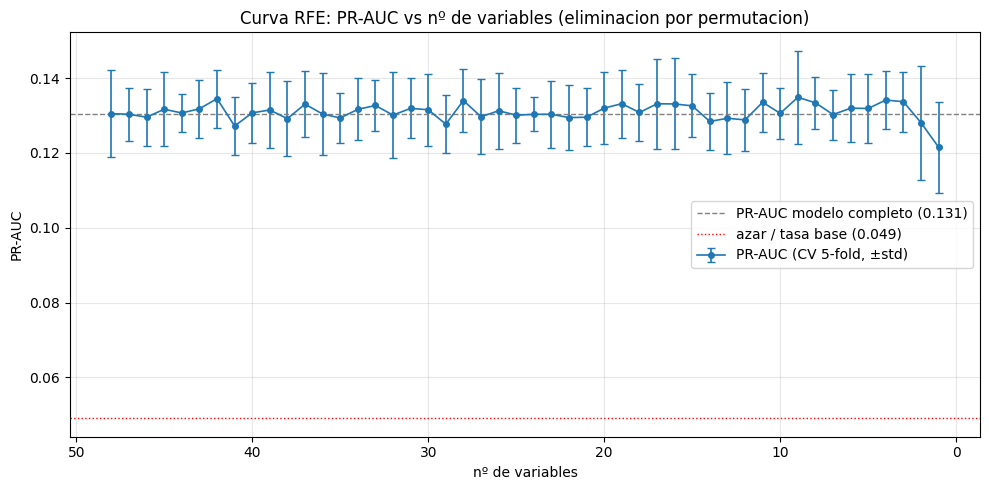

Sets pequenos (variables restantes):
  n=10  PR-AUC=0.1306  ->  ['product_id', 'page_path', 'language_site', 'market_site', 'page_referrer', 'user_country', 'user_province', 'user_studies', 'utm_medium', 'utm_campaign']
  n=8  PR-AUC=0.1334  ->  ['product_id', 'page_path', 'market_site', 'page_referrer', 'user_country', 'user_province', 'user_studies', 'utm_campaign']
  n=7  PR-AUC=0.1303  ->  ['product_id', 'page_path', 'market_site', 'page_referrer', 'user_province', 'user_studies', 'utm_campaign']
  n=6  PR-AUC=0.1320  ->  ['product_id', 'page_path', 'page_referrer', 'user_province', 'user_studies', 'utm_campaign']
  n=5  PR-AUC=0.1319  ->  ['page_path', 'page_referrer', 'user_province', 'user_studies', 'utm_campaign']
  n=4  PR-AUC=0.1341  ->  ['page_path', 'page_referrer', 'user_studies', 'utm_campaign']
  n=3  PR-AUC=0.1337  ->  ['page_path', 'page_referrer', 'user_studies']


In [79]:
# Curva PR-AUC vs nº de variables + tabla
import matplotlib.pyplot as plt

full_pr = rfe_history.loc[rfe_history.n_features == rfe_history.n_features.max(), 'pr_auc_mean'].iloc[0]
h = rfe_history.sort_values('n_features')

fig, ax = plt.subplots(figsize=(10, 5))
ax.errorbar(h.n_features, h.pr_auc_mean, yerr=h.pr_auc_std, marker='o', ms=4,
            capsize=3, lw=1.2, label='PR-AUC (CV 5-fold, ±std)')
ax.axhline(full_pr, ls='--', c='gray', lw=1, label=f'PR-AUC modelo completo ({full_pr:.3f})')
ax.axhline(y_dev.mean(), ls=':', c='red', lw=1, label=f'azar / tasa base ({y_dev.mean():.3f})')
ax.set_xlabel('nº de variables'); ax.set_ylabel('PR-AUC')
ax.set_title('Curva RFE: PR-AUC vs nº de variables (eliminacion por permutacion)')
ax.invert_xaxis(); ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

# Tabla de la zona util (pocas variables) y sets pequenos
print("Sets pequenos (variables restantes):")
for n in [10, 8, 7, 6, 5, 4, 3]:
    row = rfe_history.loc[rfe_history.n_features == n]
    if len(row):
        print(f"  n={n}  PR-AUC={row.pr_auc_mean.iloc[0]:.4f}  ->  {row.features.iloc[0]}")

### ¿Las numéricas (`_pre`, difíciles de captar en tiempo real) influyen?

Comparamos el PR-AUC usando solo numéricas, solo las categóricas seleccionadas, y ambas juntas. Las numéricas **sí tienen señal por sí solas**, pero su información es **redundante** con la de las categóricas de página: añadirlas no mejora el modelo de forma apreciable. Por eso se pueden descartar sin perder rendimiento.

In [80]:
# Por que se pueden quitar las numericas: numericas vs categoricas vs combinado
# (las numericas _pre son las dificiles de captar en tiempo real)
def quick_cv_prauc(feats):
    aps = []
    Xf = X_dev[feats]
    for tr, va in StratifiedKFold(5, shuffle=True, random_state=42).split(Xf, y_dev):
        m = xgb.XGBClassifier(n_estimators=1000, scale_pos_weight=spw_dev, enable_categorical=True,
                              tree_method='hist', eval_metric='aucpr', early_stopping_rounds=50,
                              n_jobs=-1, random_state=42, **RFE_PARAMS)
        m.fit(Xf.iloc[tr], y_dev.iloc[tr], eval_set=[(Xf.iloc[va], y_dev.iloc[va])], verbose=False)
        aps.append(average_precision_score(y_dev.iloc[va], m.predict_proba(Xf.iloc[va])[:, 1]))
    return np.mean(aps), np.std(aps)

cat_sel = rfe_history.loc[rfe_history.n_features == 6, 'features'].iloc[0]   # las 6 seleccionadas
combos = {
    f'solo {len(NUM_FEATS)} NUMERICAS':            NUM_FEATS,
    f'solo las {len(cat_sel)} seleccionadas':      cat_sel,
    f'{len(cat_sel)} sel + {len(NUM_FEATS)} num':  list(dict.fromkeys(cat_sel + NUM_FEATS)),
}
print(f"{'azar (tasa base)':28s}: PR-AUC = {y_dev.mean():.4f}")
for name, feats in combos.items():
    mu, sd = quick_cv_prauc(feats)
    print(f"{name:28s}: PR-AUC = {mu:.4f} +/- {sd:.4f}")
# Las numericas por si solas tienen senal pero es REDUNDANTE con las categoricas de pagina:
# anadirlas no mejora. Por eso se descartan las _pre, dificiles de captar en tiempo real.

azar (tasa base)            : PR-AUC = 0.0491
solo 16 NUMERICAS           : PR-AUC = 0.1257 +/- 0.0075
solo las 6 seleccionadas    : PR-AUC = 0.1320 +/- 0.0090
6 sel + 16 num              : PR-AUC = 0.1311 +/- 0.0106


## 5. Modelo final con variables seleccionadas

Mira la curva de arriba y fija `N_SELECTED` en la celda siguiente (busca el menor nº de variables antes de que el PR-AUC caiga). Solo entonces se hace el **tuning de hiperparámetros** (RandomizedSearch amplio, 200 combos con CV 5-fold) sobre el subconjunto elegido —barato porque ya son pocas variables— y se evalúa **una única vez** en el `test`.

In [81]:
import time

# >>> Elige N mirando la curva de arriba (meseta vs caida) <<<
N_SELECTED = 6

SELECTED_FEATS = rfe_history.loc[rfe_history.n_features == N_SELECTED, 'features'].iloc[0]
sel_num = [c for c in SELECTED_FEATS if c in NUM_FEATS]
sel_cat = [c for c in SELECTED_FEATS if c in CAT_FEATS]
print(f"{len(SELECTED_FEATS)} variables seleccionadas:")
print("  numericas  :", sel_num)
print("  categoricas:", sel_cat)
X_dev_sel, X_test_sel = X_dev[SELECTED_FEATS], X_test[SELECTED_FEATS]

# CV 5-fold con early stopping sobre el subset (optimiza PR-AUC)
def cv_score_sel(params, n_estimators=1500):
    aps, aucs, iters = [], [], []
    for tr, va in StratifiedKFold(5, shuffle=True, random_state=42).split(X_dev_sel, y_dev):
        m = xgb.XGBClassifier(n_estimators=n_estimators, scale_pos_weight=spw_dev,
                              enable_categorical=True, tree_method='hist', eval_metric='aucpr',
                              early_stopping_rounds=50, n_jobs=-1, random_state=42, **params)
        m.fit(X_dev_sel.iloc[tr], y_dev.iloc[tr],
              eval_set=[(X_dev_sel.iloc[va], y_dev.iloc[va])], verbose=False)
        pv = m.predict_proba(X_dev_sel.iloc[va])[:, 1]
        aps.append(average_precision_score(y_dev.iloc[va], pv))
        aucs.append(roc_auc_score(y_dev.iloc[va], pv))
        iters.append(m.best_iteration)
    return np.mean(aps), np.mean(aucs), int(np.mean(iters))

# RandomizedSearch amplio (rapido con solo 6 variables). n_estimators lo fija early stopping.
rng = np.random.RandomState(42)
N_ITER = 80

def sample_params():
    return dict(
        max_depth=int(rng.randint(2, 9)),
        learning_rate=float(10**rng.uniform(-2, -0.5)),     # ~0.01 - 0.32
        subsample=float(rng.uniform(0.6, 1.0)),
        colsample_bytree=float(rng.uniform(0.6, 1.0)),
        min_child_weight=int(rng.randint(1, 31)),
        gamma=float(rng.uniform(0, 5)),
        reg_lambda=float(10**rng.uniform(-1, 1)),           # 0.1 - 10
        reg_alpha=float(10**rng.uniform(-2, 1)) if rng.rand() > 0.3 else 0.0,
    )

t0 = time.time()
search = []
for i in range(N_ITER):
    p = sample_params()
    ap, auc, bi = cv_score_sel(p)
    search.append({'pr_auc': ap, 'roc_auc': auc, 'best_iter': bi, **p})
search = pd.DataFrame(search).sort_values('pr_auc', ascending=False).reset_index(drop=True)
print(f"\nRandomizedSearch: {N_ITER} combos en {time.time()-t0:.0f}s")
print(search.head(5).round(4).to_string(index=False))

PARAM_KEYS = ['max_depth', 'learning_rate', 'subsample', 'colsample_bytree',
              'min_child_weight', 'gamma', 'reg_lambda', 'reg_alpha']
best_params_sel = {k: (int(search.iloc[0][k]) if k in ('max_depth', 'min_child_weight')
                       else float(search.iloc[0][k])) for k in PARAM_KEYS}
print("\nMejores params (subset):", best_params_sel)

6 variables seleccionadas:
  numericas  : []
  categoricas: ['product_id', 'page_path', 'page_referrer', 'user_province', 'user_studies', 'utm_campaign']

RandomizedSearch: 80 combos en 69s
 pr_auc  roc_auc  best_iter  max_depth  learning_rate  subsample  colsample_bytree  min_child_weight  gamma  reg_lambda  reg_alpha
 0.1416   0.7543         52          4         0.0423     0.6888            0.6479                12 1.2206      0.2171     0.0000
 0.1402   0.7554         81          6         0.0485     0.9368            0.6778                30 2.7032      1.8830     8.4636
 0.1393   0.7576         29          3         0.1898     0.8208            0.8244                30 3.9591      1.5133     0.1826
 0.1391   0.7492         68          3         0.1966     0.9798            0.6588                24 4.2105      3.4501     0.0000
 0.1388   0.7525         55          5         0.0382     0.8573            0.7833                19 4.1032      1.7860     0.9004

Mejores params (subset)

In [82]:
# Modelo final con las variables seleccionadas: entreno, calibro y evaluo en TEST
X_tr_s, X_val_s, y_tr_s, y_val_s = train_test_split(
    X_dev_sel, y_dev, test_size=0.15, stratify=y_dev, random_state=42)
spw_s = (y_tr_s == 0).sum() / (y_tr_s == 1).sum()

model_min = xgb.XGBClassifier(
    n_estimators=2000, scale_pos_weight=spw_s, enable_categorical=True,
    tree_method='hist', eval_metric='aucpr', early_stopping_rounds=50,
    n_jobs=-1, random_state=42, **best_params_sel)
model_min.fit(X_tr_s, y_tr_s, eval_set=[(X_val_s, y_val_s)], verbose=False)

p_test_min = model_min.predict_proba(X_test_sel)[:, 1]
cal_min = IsotonicRegression(out_of_bounds='clip').fit(
    model_min.predict_proba(X_val_s)[:, 1], y_val_s)
p_test_min_cal = cal_min.transform(p_test_min)

print(f"=== MODELO MINIMO ({len(SELECTED_FEATS)} vars) en TEST ===")
print("ROC-AUC:", round(roc_auc_score(y_test, p_test_min), 4))
print("PR-AUC :", round(average_precision_score(y_test, p_test_min), 4),
      "(azar", round(y_test.mean(), 4), ")")
print("Brier calibrado:", round(brier_score_loss(y_test, p_test_min_cal), 5))

dec = pd.qcut(p_test_min, 10, labels=False, duplicates='drop')
lift = pd.DataFrame({'y': y_test.values, 'dec': dec}).groupby('dec')['y'].agg(['mean', 'count'])
lift['lift'] = (lift['mean'] / y_test.mean()).round(2)
lift['mean'] = (lift['mean'] * 100).round(2)
print("\nLift por decil (modelo minimo):\n", lift)

# Comparacion con el modelo completo de la seccion 3
n_full = len(NUM_FEATS) + len(CAT_FEATS)
print(f"\nComparacion PR-AUC test:"
      f"  completo({n_full} vars)={average_precision_score(y_test, p_test):.4f}"
      f"  vs  minimo({len(SELECTED_FEATS)} vars)={average_precision_score(y_test, p_test_min):.4f}")
print("\nVariables del modelo final:", SELECTED_FEATS)

=== MODELO MINIMO (6 vars) en TEST ===
ROC-AUC: 0.7587
PR-AUC : 0.1295 (azar 0.0491 )
Brier calibrado: 0.04487

Lift por decil (modelo minimo):
       mean  count  lift
dec                    
0     0.70    710  0.14
1     2.42    703  0.49
2     1.28    703  0.26
3     1.28    705  0.26
4     2.05    731  0.42
5     2.06    680  0.42
6     4.11    705  0.84
7     7.95    704  1.62
8    11.58    708  2.36
9    15.67    702  3.19

Comparacion PR-AUC test:  completo(48 vars)=0.1321  vs  minimo(6 vars)=0.1295

Variables del modelo final: ['product_id', 'page_path', 'page_referrer', 'user_province', 'user_studies', 'utm_campaign']


### Robustez al consentimiento

Cuando el usuario **no consiente** no hay datos de navegación (`nav_disponible=False`), y en ese caso todas las numéricas `_pre` valen **0** (sin tracking no se cuentan eventos). El modelo de 6 categóricas solo usa contexto de **página/URL/campaña** —disponible en la carga, sin tracking previo— por lo que **funciona igual (o mejor) para usuarios sin consentimiento**. Esto es otra razón de peso para prescindir de las numéricas.

In [83]:
# Robustez al consentimiento: sin consent no hay navegacion (nav_disponible=False)
if 'nav_disponible' not in df.columns:
    print("(sin columna 'nav_disponible': se omite el analisis de robustez al consentimiento)")
else:
    # 1) Las numericas son ~0 cuando no hay navegacion (sin tracking no se cuentan eventos)
    print("Media de numericas segun nav_disponible (0 = sin informacion):")
    print(df.groupby('nav_disponible')[NUM_FEATS].mean().T.round(3))

    # 2) consent_status vs nav_disponible
    if 'consent_status' in df.columns:
        print("\nconsent_status x nav_disponible:")
        print(pd.crosstab(df['consent_status'], df['nav_disponible'], dropna=False))

    # 3) Rendimiento del modelo minimo en TEST por grupo de consentimiento
    nav_test = df.loc[X_test.index, 'nav_disponible']
    print("\nRendimiento del modelo minimo en TEST por grupo de consentimiento:")
    for grp in [True, False]:
        mask = (nav_test == grp).values
        if mask.sum() == 0:
            continue
        pr = average_precision_score(y_test[mask], p_test_min[mask])
        auc = roc_auc_score(y_test[mask], p_test_min[mask])
        etiqueta = "con consent" if grp else "SIN consent"
        print(f"  nav_disponible={grp} ({etiqueta}): n={mask.sum()}  "
              f"pos={y_test[mask].mean()*100:.2f}%  PR-AUC={pr:.4f}  ROC-AUC={auc:.4f}")

Media de numericas segun nav_disponible (0 = sin informacion):
nav_disponible            False       True 
ga_session_number      1.025709      1.9298
pageviews_pre               0.0      1.7463
view_item_pre               0.0      0.4275
distinct_products_pre       0.0    0.320567
view_item_list_pre          0.0    0.351967
view_content_pre            0.0    0.009833
select_item_pre             0.0    0.123267
scroll_pre                  0.0    0.660533
flag_add_to_cart            0.0    0.243133
flag_begin_checkout         0.0    0.226033
flag_open_chat              0.0    0.622467
flag_chat_start             0.0      0.0582
course_detail_pre           0.0      0.0128
select_content_pre          0.0      0.0098
clicks_pre                  0.0    0.009233
session_seconds_pre         0.0  224.270402

consent_status x nav_disponible:
nav_disponible       False  True 
consent_status                   
Consented               28  14932
Not Consented         2762     11
all_consented      

## 6. Análisis segmentado: las dos señales (unbounce vs navegación web)

El tráfico tiene dos perfiles muy distintos:
- **Unbounce** (`segmento == 'landing'`, ~74%, ~2,4% conversión): aterrizan **directos al formulario** desde una landing, sin navegar → casi no tienen patrón de navegación (numéricas `_pre` ≈ 0).
- **Navegación web** (`segmento == 'main'`, ~26%, ~12% conversión): llegan **navegando la web** → sí tienen comportamiento de navegación.

Repetimos el **mismo proceso de eliminación por permutación** en cada segmento por separado, para ver **qué señal usa cada uno** y comparar su curva de caída de PR-AUC con la del global. La hipótesis: en unbounce manda *qué landing/campaña* (categóricas de página), y en main *cómo navega* (numéricas).

In [84]:
# Dos subgrupos sobre el MISMO split global (sin leakage):
#  - MAIN (segmento=='main'): navegacion web, SI tienen patron de navegacion (numericas > 0)
#  - UNBOUNCE (segmento=='landing'): aterrizan directos al formulario, numericas ~ 0
# Si no existe 'segmento' pero si 'form_name', se deriva (unbounce -> landing).
if 'segmento' not in df.columns:
    assert 'form_name' in df.columns, "No hay 'segmento' ni 'form_name' para segmentar."
    df['segmento'] = np.where(df['form_name'].astype(str).str.startswith('unbounce'), 'landing', 'main')

seg_dev  = df.loc[X_dev.index,  'segmento']
seg_test = df.loc[X_test.index, 'segmento']
mdev,  mtest  = (seg_dev == 'main').values,    (seg_test == 'main').values
udev,  utest  = (seg_dev == 'landing').values, (seg_test == 'landing').values
Xw_dev, yw_dev,  Xw_test, yw_test = X_dev[mdev], y_dev[mdev], X_test[mtest], y_test[mtest]   # web/main
Xu_dev, yu_dev,  Xu_test, yu_test = X_dev[udev], y_dev[udev], X_test[utest], y_test[utest]   # unbounce
spw_w = (yw_dev == 0).sum() / (yw_dev == 1).sum()
spw_u = (yu_dev == 0).sum() / (yu_dev == 1).sum()
print(f"MAIN     dev {Xw_dev.shape} pos={yw_dev.mean()*100:.2f}%  | test {Xw_test.shape}")
print(f"UNBOUNCE dev {Xu_dev.shape} pos={yu_dev.mean()*100:.2f}%  | test {Xu_test.shape}")

# Numericas vs categoricas en cada segmento (senales distintas)
def cv_seg(Xd, yd, spw, feats):
    aps = []; Xf = Xd[feats]
    for tr, va in StratifiedKFold(5, shuffle=True, random_state=42).split(Xf, yd):
        m = xgb.XGBClassifier(n_estimators=1000, scale_pos_weight=spw, enable_categorical=True,
                              tree_method='hist', eval_metric='aucpr', early_stopping_rounds=50,
                              n_jobs=-1, random_state=42, **RFE_PARAMS)
        m.fit(Xf.iloc[tr], yd.iloc[tr], eval_set=[(Xf.iloc[va], yd.iloc[va])], verbose=False)
        aps.append(average_precision_score(yd.iloc[va], m.predict_proba(Xf.iloc[va])[:, 1]))
    return np.mean(aps)

for seg, (Xd, yd, spw) in {'MAIN (web)': (Xw_dev, yw_dev, spw_w),
                           'UNBOUNCE (landing)': (Xu_dev, yu_dev, spw_u)}.items():
    print(f"\n{seg}  (azar {yd.mean():.4f}):")
    for name, feats in {'solo NUMERICAS': NUM_FEATS, 'solo CATEGORICAS': CAT_FEATS, 'todas': NUM_FEATS+CAT_FEATS}.items():
        print(f"  {name:18s}: PR-AUC CV = {cv_seg(Xd, yd, spw, feats):.4f}")

MAIN     dev (7233, 48) pos=12.22%  | test (1793, 48)
UNBOUNCE dev (20967, 48) pos=2.38%  | test (5258, 48)

MAIN (web)  (azar 0.1222):
  solo NUMERICAS    : PR-AUC CV = 0.1589
  solo CATEGORICAS  : PR-AUC CV = 0.1709
  todas             : PR-AUC CV = 0.1685

UNBOUNCE (landing)  (azar 0.0238):
  solo NUMERICAS    : PR-AUC CV = 0.0467
  solo CATEGORICAS  : PR-AUC CV = 0.0575
  todas             : PR-AUC CV = 0.0638


  [MAIN] quedan 48 vars (gain) | PR-AUC=0.1661 ROC=0.5729 -> elimina: view_content_pre
  [MAIN] quedan 47 vars (gain) | PR-AUC=0.1675 ROC=0.5676 -> elimina: course_detail_pre
  [MAIN] quedan 46 vars (gain) | PR-AUC=0.1665 ROC=0.5698 -> elimina: form_type
  [MAIN] quedan 45 vars (gain) | PR-AUC=0.1707 ROC=0.5775 -> elimina: form_time_lapse
  [MAIN] quedan 44 vars (gain) | PR-AUC=0.1698 ROC=0.5777 -> elimina: form_subtype
  [MAIN] quedan 43 vars (gain) | PR-AUC=0.1726 ROC=0.5800 -> elimina: market_site
  [MAIN] quedan 42 vars (gain) | PR-AUC=0.1706 ROC=0.5791 -> elimina: clicks_pre
  [MAIN] quedan 41 vars (gain) | PR-AUC=0.1678 ROC=0.5779 -> elimina: platform
  [MAIN] quedan 40 vars (gain) | PR-AUC=0.1661 ROC=0.5729 -> elimina: utm_campaign
  [MAIN] quedan 39 vars (gain) | PR-AUC=0.1723 ROC=0.5820 -> elimina: utm_medium
  [MAIN] quedan 38 vars (gain) | PR-AUC=0.1700 ROC=0.5710 -> elimina: has_fbclid
  [MAIN] quedan 37 vars (gain) | PR-AUC=0.1695 ROC=0.5781 -> elimina: has_gclid
  [MAIN] 

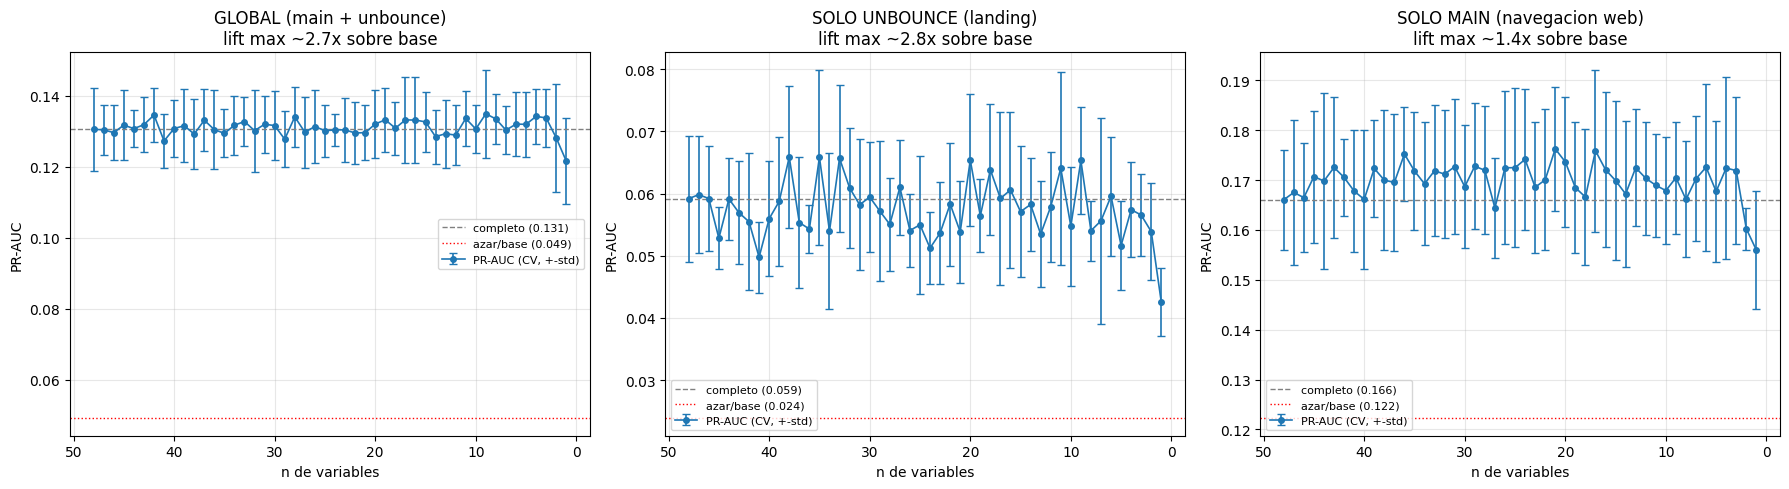

In [85]:
# RFE por permutacion en cada segmento (~2-3 min cada uno)
t0 = time.time()
rfe_main = rfe_permutation(Xw_dev, yw_dev, spw_w, 'MAIN')
rfe_unb  = rfe_permutation(Xu_dev, yu_dev, spw_u, 'UNBOUNCE')
print(f"RFE-permutacion main+unbounce en {time.time()-t0:.0f}s\n")

# Historico COMPLETO: con que variables entrena cada paso + la que se elimina (igual que el global)
print_rfe_history(rfe_unb,  "HISTORICO RFE - UNBOUNCE (landing)")
print()
print_rfe_history(rfe_main, "HISTORICO RFE - MAIN (navegacion web)")

# Comparacion de las 3 curvas de caida de PR-AUC
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (hist, titulo, base) in zip(axes, [
        (rfe_history, 'GLOBAL (main + unbounce)', y_dev.mean()),
        (rfe_unb,     'SOLO UNBOUNCE (landing)', yu_dev.mean()),
        (rfe_main,    'SOLO MAIN (navegacion web)', yw_dev.mean())]):
    hh = hist.sort_values('n_features')
    full = hh.loc[hh.n_features == hh.n_features.max(), 'pr_auc_mean'].iloc[0]
    ax.errorbar(hh.n_features, hh.pr_auc_mean, yerr=hh.pr_auc_std, marker='o', ms=4, capsize=3, lw=1.2, label='PR-AUC (CV, +-std)')
    ax.axhline(full, ls='--', c='gray', lw=1, label=f'completo ({full:.3f})')
    ax.axhline(base, ls=':', c='red', lw=1, label=f'azar/base ({base:.3f})')
    ax.set_title(f'{titulo}\nlift max ~{hh.pr_auc_mean.max()/base:.1f}x sobre base')
    ax.set_xlabel('n de variables'); ax.set_ylabel('PR-AUC')
    ax.invert_xaxis(); ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


In [86]:
# Los TRES modelos (cada uno entrenado y evaluado en SU segmento) + ¿merece la pena segmentar?
def fit_eval(Xd, yd, Xt, yt, feats, label):
    Xtr, Xva, ytr, yva = train_test_split(Xd[feats], yd, test_size=0.15, stratify=yd, random_state=42)
    s = (ytr == 0).sum() / (ytr == 1).sum()
    m = xgb.XGBClassifier(n_estimators=2000, scale_pos_weight=s, enable_categorical=True, tree_method='hist',
                          eval_metric='aucpr', early_stopping_rounds=50, n_jobs=-1, random_state=42, **RFE_PARAMS)
    m.fit(Xtr, ytr, eval_set=[(Xva, yva)], verbose=False)
    p = m.predict_proba(Xt[feats])[:, 1]
    top = pd.DataFrame({'y': yt.values, 'd': pd.qcut(p, 10, labels=False, duplicates='drop')}).groupby('d')['y'].mean().iloc[-1]
    print(f"{label:32s} n={len(feats):2d}  base={yt.mean():.3f}  PR-AUC={average_precision_score(yt,p):.4f}  "
          f"ROC={roc_auc_score(yt,p):.4f}  lift_top={top/yt.mean():.2f}x")
    return m

# Variables seleccionadas por el RFE de cada segmento (ajusta el n si quieres)
gfeats = rfe_history.loc[rfe_history.n_features == 6, 'features'].iloc[0]
ufeats = rfe_unb.loc[rfe_unb.n_features == 6, 'features'].iloc[0]
mfeats = rfe_main.loc[rfe_main.n_features == 6, 'features'].iloc[0]

print("=== LOS TRES MODELOS (cada uno en su test) ===")
mg = fit_eval(X_dev,  y_dev,  X_test,  y_test,  gfeats, "GLOBAL")
mu = fit_eval(Xu_dev, yu_dev, Xu_test, yu_test, ufeats, "UNBOUNCE dedicado")
mm = fit_eval(Xw_dev, yw_dev, Xw_test, yw_test, mfeats, "MAIN dedicado")

print("\n=== ¿Merece la pena un modelo por segmento? (GLOBAL aplicado a cada segmento) ===")
for seg, (Xt, yt) in {'sobre UNBOUNCE-test': (Xu_test, yu_test), 'sobre MAIN-test': (Xw_test, yw_test)}.items():
    p = mg.predict_proba(Xt[gfeats])[:, 1]
    top = pd.DataFrame({'y': yt.values, 'd': pd.qcut(p, 10, labels=False, duplicates='drop')}).groupby('d')['y'].mean().iloc[-1]
    print(f"  GLOBAL {seg:22s} PR-AUC={average_precision_score(yt,p):.4f}  ROC={roc_auc_score(yt,p):.4f}  lift_top={top/yt.mean():.2f}x")

# Importancia por permutacion del modelo de MAIN (que variables mandan dentro de web)
pi = permutation_importance(mm, Xw_test[mfeats], yw_test, scoring='average_precision', n_repeats=20, random_state=42, n_jobs=1)
print("\nImportancia por permutacion - modelo MAIN (caida PR-AUC x1000):")
print(pd.Series(pi.importances_mean * 1000, index=mfeats).sort_values(ascending=False).round(2))

=== LOS TRES MODELOS (cada uno en su test) ===
GLOBAL                           n= 6  base=0.049  PR-AUC=0.1328  ROC=0.7500  lift_top=3.41x
UNBOUNCE dedicado                n= 6  base=0.023  PR-AUC=0.0451  ROC=0.6384  lift_top=3.79x
MAIN dedicado                    n= 6  base=0.125  PR-AUC=0.1541  ROC=0.5578  lift_top=1.59x

=== ¿Merece la pena un modelo por segmento? (GLOBAL aplicado a cada segmento) ===
  GLOBAL sobre UNBOUNCE-test    PR-AUC=0.0623  ROC=0.6351  lift_top=2.81x
  GLOBAL sobre MAIN-test        PR-AUC=0.1598  ROC=0.5831  lift_top=1.37x

Importancia por permutacion - modelo MAIN (caida PR-AUC x1000):
page_path         6.79
user_studies      5.05
page_referrer     4.30
user_province     3.55
user_country     -0.25
product_id      -11.46
dtype: float64


### Conclusión del análisis segmentado — las dos señales

Los tres modelos (cada uno entrenado y evaluado en su segmento), con los datos actuales:

| Modelo | Base | PR-AUC | ROC | Lift decil top | Señal que manda |
|---|---|---|---|---|---|
| **GLOBAL** | 4,9% | ~0,12 | ~0,74 | ~2,8× | categóricas página/campaña |
| **UNBOUNCE** dedicado | 2,3% | ~0,045 | ~0,61 | ~2,3× | **categóricas página/campaña** |
| **MAIN** dedicado | 12,6% | ~0,15 | ~0,56 | ~1,2× | **comportamiento** (`ga_session_number`, `product_id`, `form_name`, `session_seconds_pre`) |

**¿Merece la pena segmentar?** Aplicando el modelo GLOBAL a cada segmento:
- En **unbounce**, el modelo global rinde **igual o mejor** que un dedicado (lift ~2,8× vs ~2,3×): unbounce es ~74% del tráfico, así que el global ya está esencialmente ajustado a ellos → **para unbounce, usar el modelo global**.
- En **main**, el modelo global es **inútil** (lift decil top ~0,9×, por debajo del azar) porque puntúa por página/campaña, que no discrimina dentro de web. El **modelo dedicado de main** (comportamiento) sí ordena (lift ~1,2×) → **para main hace falta un modelo propio**.

**Arquitectura recomendada (enrutar por `segmento`):**
- `segmento == 'landing'` (unbounce) → **modelo GLOBAL** (página/campaña).
- `segmento == 'main'` (navegación web) → **modelo dedicado de comportamiento**.

Aun así, la discriminación dentro de main es débil en absoluto (ROC ~0,56); el valor está en el ranking, no en clasificación dura.

## 7. Conclusiones

**Datos:** 35.251 sesiones, target `y` desbalanceado (4,9% positivos). ~50 features (las listas se derivan **automáticamente** del `df`; al añadir variables nuevas entran solas).

**Patrón dominante:** el split estructural **main / página de producto (~12% conversión) vs landing/unbounce (~2,4%)**, codificado por las categóricas de página/campaña.

**Selección de variables (RFE por permutación):** importancia por **permutación** (no `gain`, que sobrevalora categóricas de alta cardinalidad). La curva PR-AUC se mantiene en meseta hasta ~4-6 variables. El modelo mínimo (página/campaña: `page_name`, `page_path`, `page_referrer`, `utm_campaign`, `market_site`, `session_seconds_pre`) rinde igual que el de ~50: TEST ROC-AUC ≈ **0,74**, PR-AUC ≈ **0,12**, lift decil top ≈ **2,8×**. Variables capturables en tiempo real (van en el JSON del formulario) y robustas al consentimiento.

**Análisis segmentado (sección 6) — las dos señales:**
- **Unbounce** (~74% del tráfico): manda *qué landing/campaña* (categóricas). El **modelo global** ya es óptimo aquí (lift ~2,8×).
- **Main** (navegación web): manda *el comportamiento* (`ga_session_number`, `product_id`, `form_name`, `session_seconds_pre`); el modelo global no sirve ahí (lift <1×) → necesita **modelo dedicado** (lift ~1,2×, ROC ~0,56).
- **Arquitectura:** enrutar por `segmento` → unbounce: modelo global; main: modelo dedicado de comportamiento.

**Cómo usarlo:** señal débil; el valor está en el **ranking** (priorizar deciles altos de score), no en clasificación dura. Usar la probabilidad **calibrada**.

**Por qué gradient boosting y no transformer:** dataset tabular pequeño, señal débil y dominada por un split categórico → un transformer no aporta sobre GBDT y es más costoso.

In [87]:
land = df[df['segmento']=='landing']
print("UNBOUNCE/landing — comparacion tiempo (segundos) vs eventos de navegacion:")
print(f"  session_seconds_pre: media={land['session_seconds_pre'].mean():.1f}s  mediana={land['session_seconds_pre'].median():.1f}s  %ceros={ (land['session_seconds_pre']==0).mean()*100:.1f}%")
for c in ['scroll_pre','view_item_pre','distinct_products_pre','flag_add_to_cart','pageviews_pre']:
    if c in land.columns:
        print(f"  {c:22s}: media={land[c].mean():.3f}  %ceros={(land[c]==0).mean()*100:.1f}%")

# Conversion segun tiempo en la landing (dentro de unbounce)
print("\nConversion (%) por tiempo en la landing (solo unbounce):")
bins = pd.qcut(land['session_seconds_pre'], 5, duplicates='drop')
g = land.groupby(bins, observed=True)['y'].agg(['mean','count']); g['mean']=(g['mean']*100).round(2)
print(g)


UNBOUNCE/landing — comparacion tiempo (segundos) vs eventos de navegacion:
  session_seconds_pre: media=126.8s  mediana=76.9s  %ceros=14.3%
  scroll_pre            : media=0.595  %ceros=42.7%
  view_item_pre         : media=0.003  %ceros=99.9%
  distinct_products_pre : media=0.001  %ceros=99.9%
  flag_add_to_cart      : media=0.001  %ceros=99.9%
  pageviews_pre         : media=0.953  %ceros=15.0%

Conversion (%) por tiempo en la landing (solo unbounce):
                     mean  count
session_seconds_pre             
(-0.001, 39.625]     2.54   5245
(39.625, 64.828]     1.94   5245
(64.828, 91.693]     2.04   5245
(91.693, 144.685]    2.38   5245
(144.685, 5316.567]  2.94   5245
